# Autoencoders
Autoencoders are a type of neural network that learns to compress and reconstruct data. They consist of an encoder that maps the input to a lower-dimensional latent space, and a decoder that maps the latent space back to the original input.

## Table of Contents
1. [Vanilla Autoencoder](#vanilla-autoencoder)
2. [Sparse Autoencoder](#sparse-autoencoder)
3. [Denoising Autoencoder](#denoising-autoencoder)
4. [Contractive Autoencoder](#contractive-autoencoder)
5. [Variational Autoencoder (VAE)](#variational-autoencoder-vae)
6. [Undercomplete Autoencoder](#undercomplete-autoencoder)
7. [Stacked Autoencoder](#stacked-autoencoder)
8. [Convolutional Autoencoder](#convolutional-autoencoder)
9. [Deep Autoencoder](#deep-autoencoder)

## Vanilla Autoencoder
### Description
The simplest form of an autoencoder, consisting of an encoder that compresses the input into a latent-space representation and a decoder that reconstructs the input from the latent space.

### Diagram
* **Encoder:** Input → Dense layers → Latent Space (bottleneck)
* **Decoder:** Latent Space → Dense layers → Reconstructed Input

#### Encoding
$$
z = f_{\theta}(x) = \sigma(W_e \cdot x + b_e)
$$
where:
* $x$: Input
* $W_e, b_e$: Encoder weights and biases
* $\sigma$: Activation function

#### Decoding
$$
\hat{x} = g_{\phi}(z) = \sigma(W_d \cdot z + b_d)
$$
where:
* $\hat{x}$: Reconstructed input
* $W_d, b_d$: Decoder weights and biases

#### Loss Function
Mean Squared Error (MSE):
$$
\mathcal{L} = \frac{1}{n} \sum_{i=1}^{n} (x_i - \hat{x}_i)^2
$$

### Regularization
* L2 regularization on weights: 
$$
\lambda \sum ||W||_2^2
$$
* Dropout to prevent overfitting

## Sparse Autoencoder
### Description
Imposes a sparsity constraint on the latent representation, forcing most of the activations in the hidden layer to be close to zero.

### Diagram
Similar to a Vanilla Autoencoder but with sparsity constraints on the bottleneck layer.

#### Loss Function
$$
\mathcal{L} = \mathcal{L}_{reconstruction} + \beta \sum_{j} \text{KL}(\rho || \hat{\rho}_j)
$$
where:
* $\text{KL}(\rho || \hat{\rho}_j)$: Kullback-Leibler divergence between average activation $\hat{\rho}_j$ and target sparsity $\rho$
* $\beta$: Weight of the sparsity penalty

## Denoising Autoencoder
### Description
Trains the autoencoder to reconstruct the original input from a noisy version, enhancing robustness.

### Diagram
* Input with noise → Encoder → Bottleneck → Decoder → Reconstructed clean input

#### Encoding
$$
z = f_{\theta}(x + \text{noise})
$$
where:
* $x + \text{noise}$: Input corrupted with random noise

#### Loss Function
$$
\mathcal{L} = \frac{1}{n} \sum_{i=1}^{n} (x_i - \hat{x}_i)^2
$$

### Regularization
* Noise addition acts as implicit regularization

## Contractive Autoencoder
### Description
Applies a penalty to encourage the latent space to be sensitive to small variations in the input.

### Diagram
Same as a Vanilla Autoencoder but with a regularization term on the encoder.

#### Loss Function
$$
\mathcal{L} = \mathcal{L}_{reconstruction} + \lambda \cdot ||\nabla_z f_{\theta}(x)||^2
$$
where:
* $\nabla_z f_{\theta}(x)$: Jacobian matrix of the encoder

## Variational Autoencoder (VAE)
### Description
A probabilistic autoencoder that models the latent space as a probability distribution.

### Diagram
* Encoder outputs mean $\mu$ and variance $\sigma^2$
* Latent space uses reparameterization trick: $z = \mu + \sigma \cdot \epsilon$

#### Latent Space Sampling
$$
z = \mu + \sigma \cdot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)
$$

#### Loss Function
$$
\mathcal{L} = \mathcal{L}_{reconstruction} + \text{KL}(q(z|x) || p(z))
$$
where:
* $\text{KL}(q(z|x) || p(z))$: Kullback-Leibler divergence between learned latent distribution $q(z|x)$ and prior $p(z)$

### Regularization
* KL divergence acts as the regularizer

## Undercomplete Autoencoder
### Description
Similar to a Vanilla Autoencoder but with the latent space dimension $ < $ input dimension. Encourages the autoencoder to learn compact representations.

### Diagram
Input → Smaller bottleneck → Decoder → Reconstructed Input

Same as Vanilla Autoencoder, but with $\text{dim}(z) < \text{dim}(x)$

## Stacked Autoencoder
### Description
A deep architecture where multiple autoencoders are stacked together.

### Diagram
* Layered structure: Encoder and decoder each consist of multiple layers

The encoding and decoding processes are stacked:
$$
z^{(l)} = f_{\theta^{(l)}}(z^{(l-1)})
$$
for each layer $l$

## Convolutional Autoencoder
### Description
Uses convolutional layers instead of fully connected layers, suitable for image data.

### Diagram
* Input → Conv layers → Bottleneck → Deconv layers → Reconstructed input

#### Encoding and Decoding via Convolution
Convolutional and deconvolutional operations replace matrix multiplication

#### Loss Function
MSE or Cross-Entropy Loss

### Regularization
* Weight decay, Dropout, or Batch Normalization

## Deep Autoencoder
### Description
A multi-layer architecture with several hidden layers for both encoder and decoder.

### Diagram
Similar to a Stacked Autoencoder, but trained end-to-end

$$
z^{(l)} = f_{\theta^{(l)}}(f_{\theta^{(l-1)}}(...f_{\theta^{(1)}}(x)))
$$

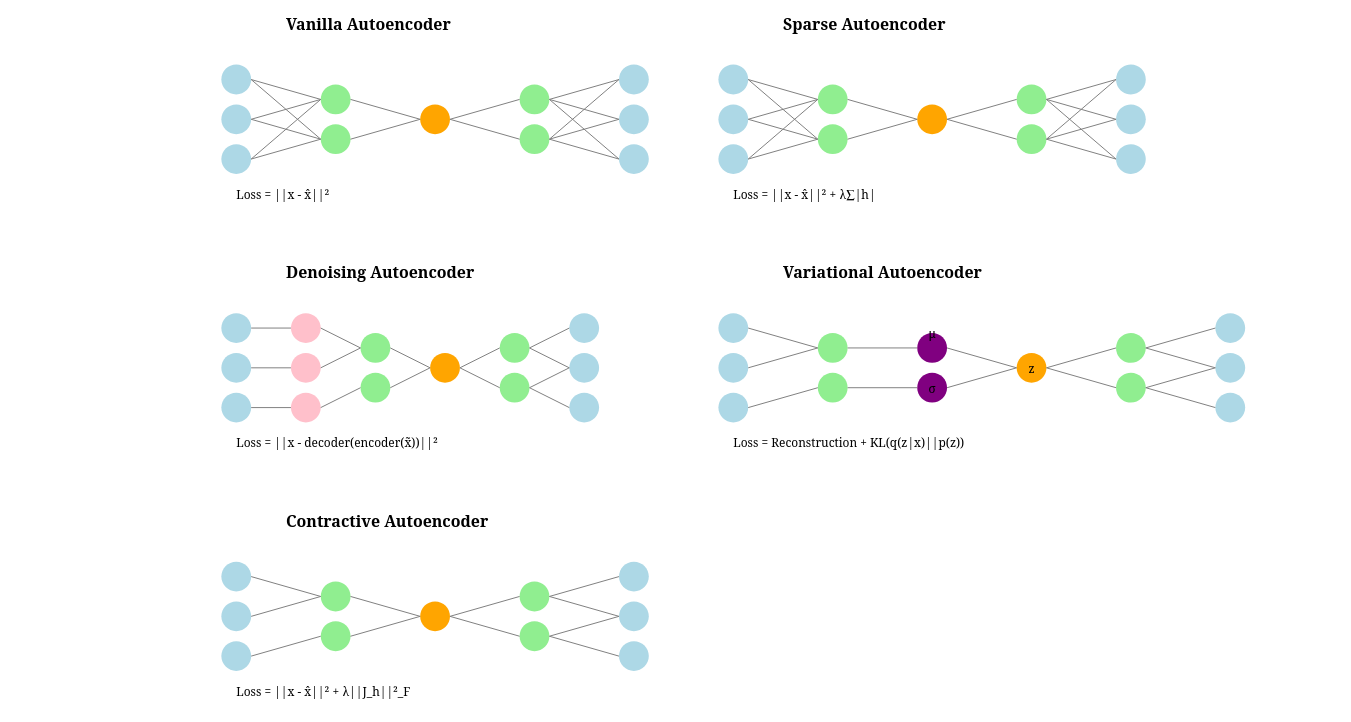